# Twitter Sentiment Analysis
### Multi-Class NLP with Machine Learning — Positive, Negative & Neutral

## Step 1: Install Required Libraries

In [1]:
pip install pandas scikit-learn matplotlib seaborn wordcloud emoji vaderSentiment joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Upload the Dataset


In [2]:
# from google.colab import files
# uploaded = files.upload()

## Step 3: Load and Explore the Dataset



In [3]:
import pandas as pd

df = pd.read_csv(
    'training.1600000.processed.noemoticon.csv',
    encoding='latin-1', header=None
)
df = df[[0, 5]]
df.columns = ['polarity', 'text']
df = df[df['polarity'] != 2]
df['polarity'] = df['polarity'].map({0: 0, 4: 1})

print(f'Dataset shape     : {df.shape}')
print(f'\nClass distribution:')
print(df['polarity'].value_counts().rename({0:'Negative', 1:'Positive'}))
print(f'\nSample tweets:')
print(df[['text', 'polarity']].head(5).to_string())

Dataset shape     : (1600000, 2)

Class distribution:
polarity
Negative    800000
Positive    800000
Name: count, dtype: int64

Sample tweets:
                                                                                                                  text  polarity
0  @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D         0
1      is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!         0
2                            @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds         0
3                                                                      my whole body feels itchy and like its on fire          0
4      @nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.          0


## Step 4: Exploratory Data Analysis (EDA)

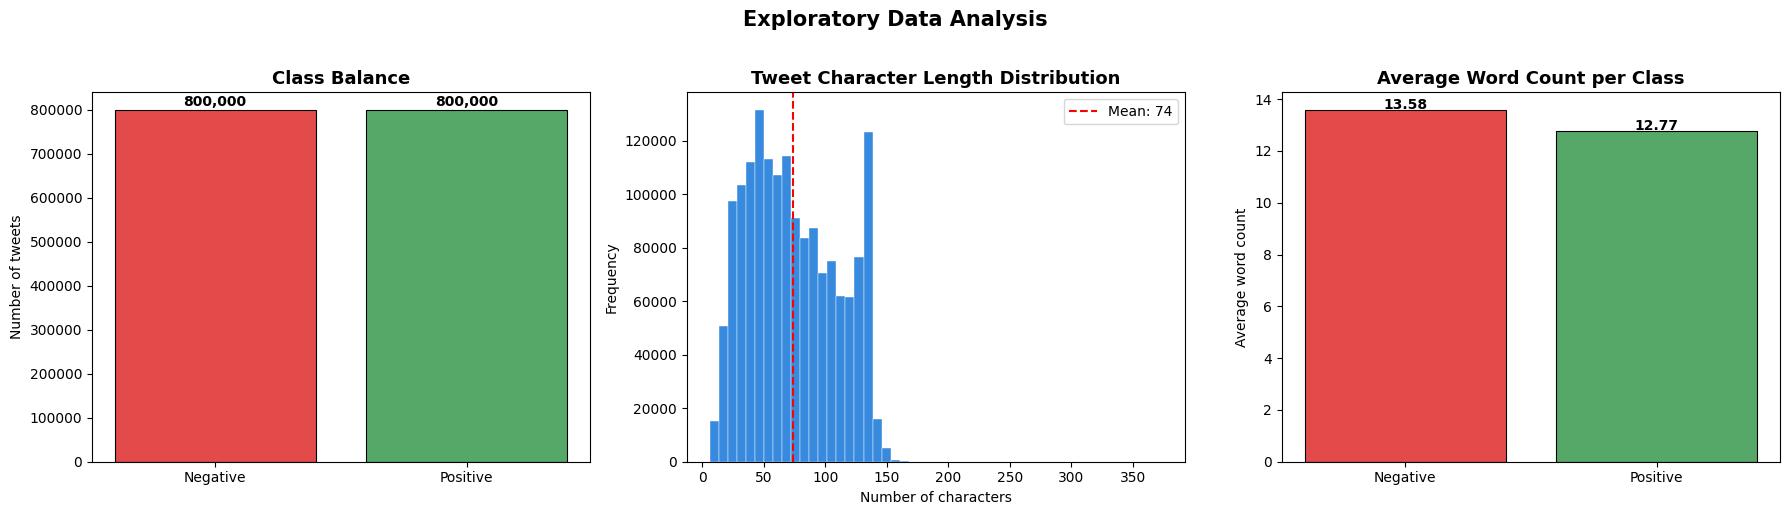

EDA plots saved.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df['tweet_length'] = df['text'].apply(len)
df['word_count']   = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class balance
counts = df['polarity'].value_counts()
axes[0].bar(['Negative', 'Positive'], counts.values, color=['#E24B4A', '#55A868'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Balance', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of tweets')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 8000, f'{v:,}', ha='center', fontweight='bold')

# 2. Tweet length distribution
axes[1].hist(df['tweet_length'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.3)
axes[1].set_title('Tweet Character Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of characters')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['tweet_length'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["tweet_length"].mean():.0f}')
axes[1].legend()

# 3. Average word count per class
avg_words = df.groupby('polarity')['word_count'].mean()
axes[2].bar(['Negative', 'Positive'], avg_words.values, color=['#E24B4A', '#55A868'], edgecolor='black', linewidth=0.8)
axes[2].set_title('Average Word Count per Class', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Average word count')
for i, v in enumerate(avg_words.values):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight', dpi=150)
plt.show()
print('EDA plots saved.')

## Step 5: Advanced Text Preprocessing

In [5]:
import re
import emoji

# Tier 1: Slang dictionary
SLANG = {
    'lol':'laughing out loud','omg':'oh my god','idk':"i don't know",
    'tbh':'to be honest','ngl':'not gonna lie','smh':'shaking my head',
    'brb':'be right back','imo':'in my opinion','ikr':'i know right',
    'ily':'i love you','wtf':'what the heck','thx':'thanks',
    'tysm':'thank you so much','rn':'right now','gr8':'great',
    'b4':'before','luv':'love','haha':'laughing','hahaha':'very funny',
    'omfg':'oh my god','fml':'this is terrible','yolo':'you only live once',
    '2day':'today','4ever':'forever','asap':'as soon as possible',
}

def expand_slang(text):
    return ' '.join(SLANG.get(w, w) for w in text.split())

def clean_text(text):
    # Stage 1: convert emojis to words
    text = emoji.demojize(text, delimiters=(' ', ' '))
    # Stage 2: lowercase
    text = text.lower()
    # Stage 3: expand slang
    text = expand_slang(text)
    # Stage 4: remove URLs and @mentions
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    # Stage 5: keep hashtag words
    text = re.sub(r'#(\w+)', r'\1', text)
    # Stage 6: remove punctuation/numbers, clean whitespace
    text = re.sub(r'[^a-z\s_]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Applying cleaning pipeline to 1.6M tweets (may take a minute)...')
df['clean_text'] = df['text'].apply(clean_text)
print('Done!\n')

print('Before vs after cleaning:')
print('-' * 70)
for i in range(4):
    print(f'BEFORE: {df["text"].iloc[i]}')
    print(f'AFTER : {df["clean_text"].iloc[i]}')
    print()

Applying cleaning pipeline to 1.6M tweets (may take a minute)...
Done!

Before vs after cleaning:
----------------------------------------------------------------------
BEFORE: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
AFTER : a thats a bummer you shoulda got david carr of third day to do it d

BEFORE: is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
AFTER : is upset that he cant update his facebook by texting it and might cry as a result school today also blah

BEFORE: @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
AFTER : i dived many times for the ball managed to save the rest go out of bounds

BEFORE: my whole body feels itchy and like its on fire 
AFTER : my whole body feels itchy and like its on fire



## Step 6: Word Cloud Visualization

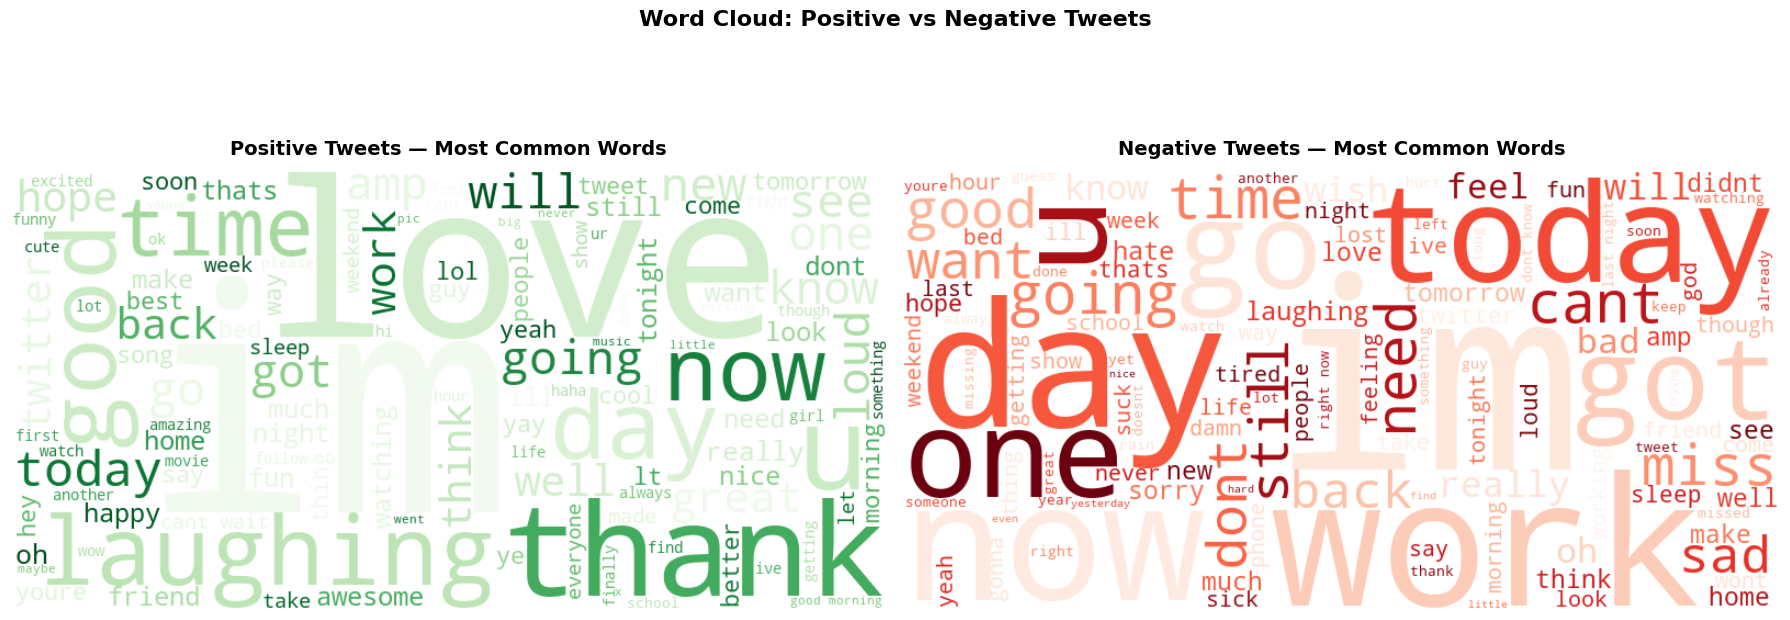

In [6]:
from wordcloud import WordCloud

pos_text = ' '.join(df[df['polarity'] == 1]['clean_text'].sample(10000, random_state=42))
neg_text = ' '.join(df[df['polarity'] == 0]['clean_text'].sample(10000, random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.imshow(
    WordCloud(width=800, height=400, background_color='white',
              colormap='Greens', max_words=120).generate(pos_text),
    interpolation='bilinear'
)
ax1.set_title('Positive Tweets — Most Common Words', fontsize=14, fontweight='bold', pad=12)
ax1.axis('off')

ax2.imshow(
    WordCloud(width=800, height=400, background_color='white',
              colormap='Reds', max_words=120).generate(neg_text),
    interpolation='bilinear'
)
ax2.set_title('Negative Tweets — Most Common Words', fontsize=14, fontweight='bold', pad=12)
ax2.axis('off')

plt.suptitle('Word Cloud: Positive vs Negative Tweets', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordcloud.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 7: Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['polarity'], test_size=0.2, random_state=42
)
print(f'Training samples : {len(X_train):,}')
print(f'Testing samples  : {len(X_test):,}')

Training samples : 1,280,000
Testing samples  : 320,000


## Step 8: TF-IDF Vectorization


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# stop_words='english' is the Tier 1 stopword removal upgrade
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'Feature matrix shape (train): {X_train_tfidf.shape}')
print(f'Feature matrix shape (test) : {X_test_tfidf.shape}')
print(f'Each tweet is now a vector of {X_train_tfidf.shape[1]:,} features.')

Feature matrix shape (train): (1280000, 5000)
Feature matrix shape (test) : (320000, 5000)
Each tweet is now a vector of 5,000 features.


## Step 9: Train Three ML Models + VADER Baseline


In [9]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Bernoulli Naive Bayes
print('Training Bernoulli Naive Bayes...')
bnb = BernoulliNB()
bnb.fit(X_train_tfidf, y_train)
bnb_pred = bnb.predict(X_test_tfidf)
print(f'  Accuracy: {accuracy_score(y_test, bnb_pred):.4f}')

# Support Vector Machine
print('Training Support Vector Machine...')
svm = LinearSVC(max_iter=1000)
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)
print(f'  Accuracy: {accuracy_score(y_test, svm_pred):.4f}')

# Logistic Regression
print('Training Logistic Regression...')
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train)
logreg_pred = logreg.predict(X_test_tfidf)
print(f'  Accuracy: {accuracy_score(y_test, logreg_pred):.4f}')

# VADER (Tier 1 rule-based baseline — no training needed)
print('Running VADER baseline...')
vader = SentimentIntensityAnalyzer()
vader_pred = [
    1 if vader.polarity_scores(t)['compound'] >= 0 else 0
    for t in X_test
]
print(f'  Accuracy: {accuracy_score(y_test, vader_pred):.4f}')
print('\nAll models trained!')

Training Bernoulli Naive Bayes...
  Accuracy: 0.7565
Training Support Vector Machine...
  Accuracy: 0.7661
Training Logistic Regression...
  Accuracy: 0.7668
Running VADER baseline...
  Accuracy: 0.6640

All models trained!


## Step 10: Model Evaluation — Accuracy, Reports & Confusion Matrices



  Naive Bayes — Accuracy: 0.7565 (75.65%)
              precision    recall  f1-score   support

    Negative       0.77      0.73      0.75    159494
    Positive       0.74      0.78      0.76    160506

    accuracy                           0.76    320000
   macro avg       0.76      0.76      0.76    320000
weighted avg       0.76      0.76      0.76    320000


  SVM — Accuracy: 0.7661 (76.61%)
              precision    recall  f1-score   support

    Negative       0.78      0.73      0.76    159494
    Positive       0.75      0.80      0.77    160506

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000


  Logistic Regression — Accuracy: 0.7668 (76.68%)
              precision    recall  f1-score   support

    Negative       0.78      0.74      0.76    159494
    Positive       0.75      0.79      0.77    160506

    accuracy                           0.77    320000

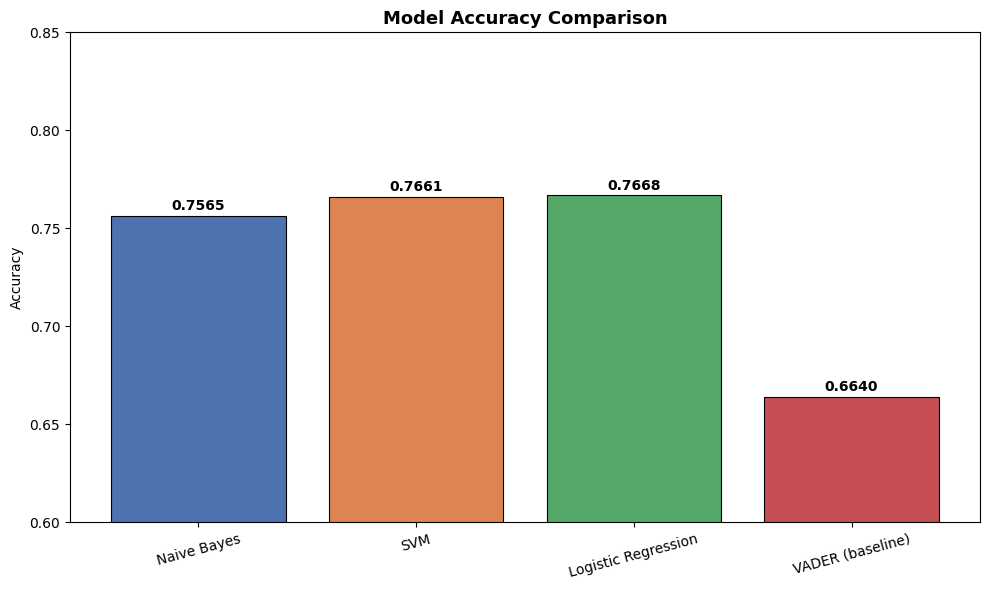

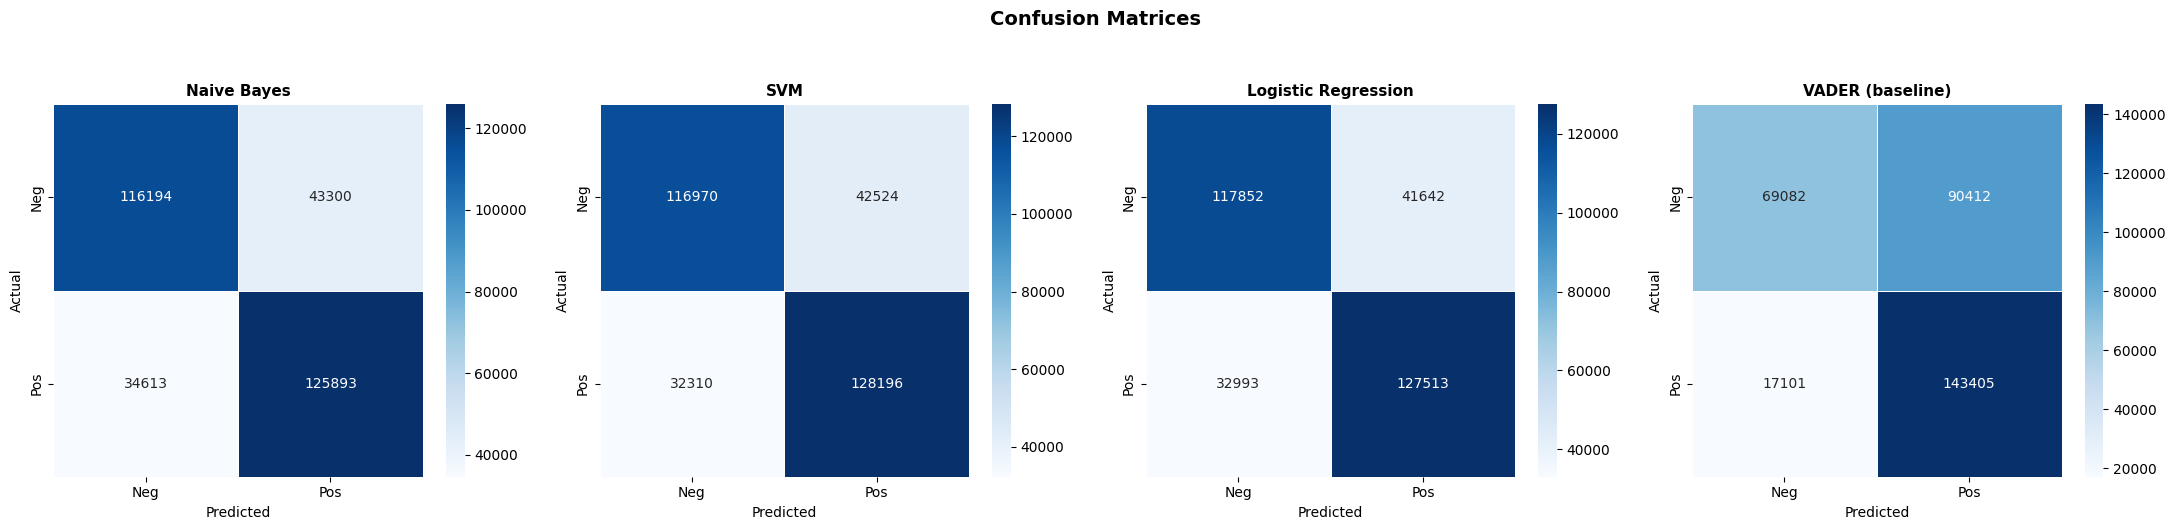


Best model: Logistic Regression with accuracy 0.7668


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

models_info = [
    ('Naive Bayes',         bnb_pred),
    ('SVM',                 svm_pred),
    ('Logistic Regression', logreg_pred),
    ('VADER (baseline)',    vader_pred),
]

# Print classification reports
for name, pred in models_info:
    acc = accuracy_score(y_test, pred)
    print(f'\n{"="*55}')
    print(f'  {name} — Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print('='*55)
    print(classification_report(y_test, pred, target_names=['Negative', 'Positive']))

# Accuracy bar chart
names      = [n for n, _ in models_info]
accuracies = [accuracy_score(y_test, p) for _, p in models_info]
colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Changed to (1, 1) to avoid an empty second plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

bars = ax.bar(names, accuracies, color=colors, edgecolor='black', linewidth=0.8)
ax.set_ylim(0.6, 0.85)
ax.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=15)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

# Confusion matrices (1x4 grid)
fig2, axes2 = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, pred) in zip(axes2, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
                linewidths=0.5)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

best = max(zip(names, accuracies), key=lambda x: x[1])
print(f'\nBest model: {best[0]} with accuracy {best[1]:.4f}')

## Step 11: ROC-AUC Curves

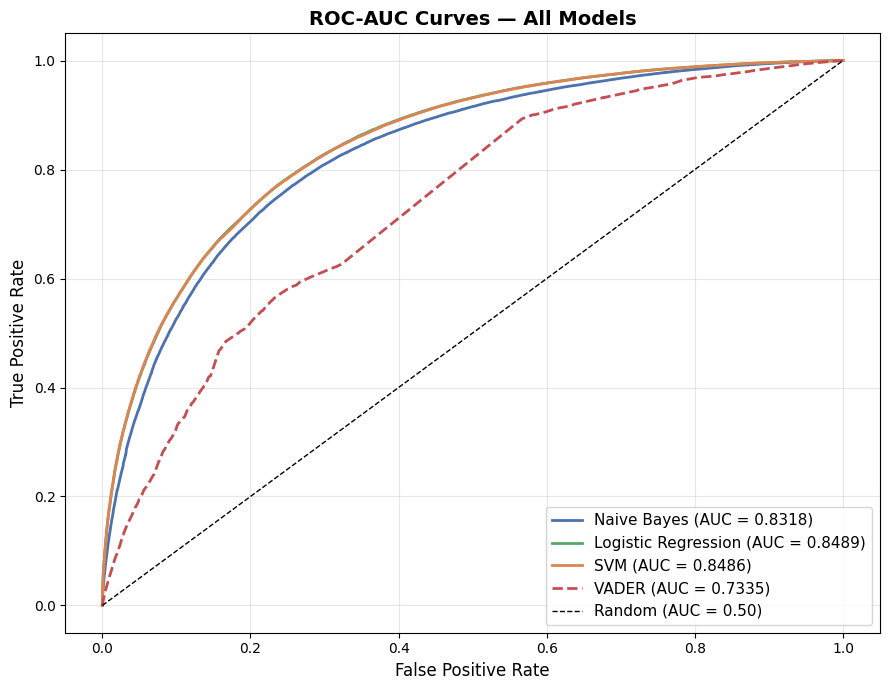

ROC-AUC curves saved.


In [11]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))

roc_models = [
    ('Naive Bayes',         bnb,    '#4C72B0'),
    ('Logistic Regression', logreg, '#55A868'),
]
# Note: LinearSVC uses decision_function instead of predict_proba
roc_models_svm = [('SVM', svm, '#DD8452')]

for name, model, color in roc_models:
    probs = model.predict_proba(X_test_tfidf)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color, linewidth=2)

for name, model, color in roc_models_svm:
    scores = model.decision_function(X_test_tfidf)
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color, linewidth=2)

# VADER
vader_scores = [vader.polarity_scores(t)['compound'] for t in X_test]
fpr_v, tpr_v, _ = roc_curve(y_test, vader_scores)
roc_auc_v = auc(fpr_v, tpr_v)
plt.plot(fpr_v, tpr_v, label=f'VADER (AUC = {roc_auc_v:.4f})', color='#C44E52', linewidth=2, linestyle='--')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print('ROC-AUC curves saved.')

## Step 12: Cross-Validation

Running 5-Fold Cross-Validation (may take a few minutes)...

Naive Bayes:
  Fold scores : ['0.7570', '0.7559', '0.7557', '0.7563', '0.7567']
  Mean        : 0.7563
  Std Dev     : 0.0005  (lower = more consistent)

SVM:
  Fold scores : ['0.7667', '0.7654', '0.7660', '0.7650', '0.7664']
  Mean        : 0.7659
  Std Dev     : 0.0006  (lower = more consistent)

Logistic Regression:
  Fold scores : ['0.7670', '0.7660', '0.7666', '0.7664', '0.7670']
  Mean        : 0.7666
  Std Dev     : 0.0004  (lower = more consistent)



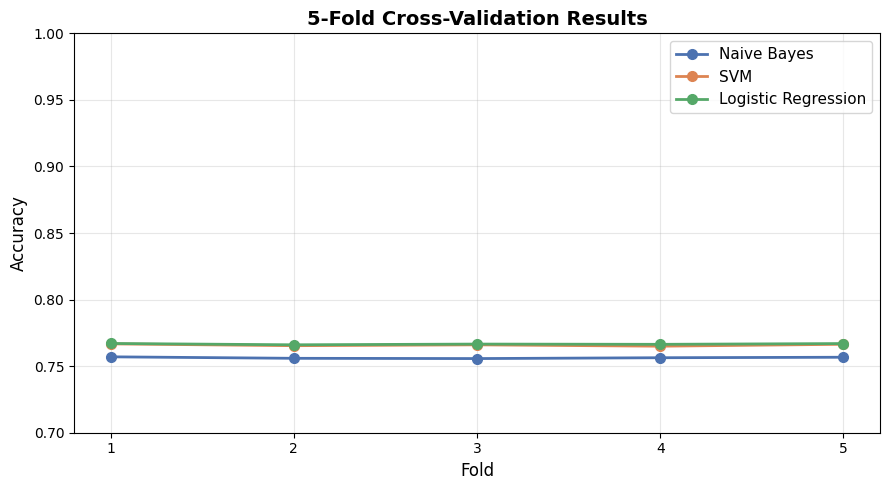

In [12]:
from sklearn.model_selection import cross_val_score

print('Running 5-Fold Cross-Validation (may take a few minutes)...\n')

cv_results = {}
for name, model in [('Naive Bayes', bnb), ('SVM', svm), ('Logistic Regression', logreg)]:
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  Fold scores : {[f"{s:.4f}" for s in scores]}')
    print(f'  Mean        : {scores.mean():.4f}')
    print(f'  Std Dev     : {scores.std():.4f}  (lower = more consistent)\n')

# Cross-validation line chart
plt.figure(figsize=(9, 5))
cv_colors = {'Naive Bayes': '#4C72B0', 'SVM': '#DD8452', 'Logistic Regression': '#55A868'}
for name, scores in cv_results.items():
    plt.plot(range(1, 6), scores, marker='o', label=name,
             linewidth=2, markersize=7, color=cv_colors[name])

plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
plt.xticks(range(1, 6))
plt.legend(fontsize=11)
plt.ylim(0.70, 1.0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150)
plt.show()

## Step 13: Hyperparameter Tuning with GridSearchCV

Running GridSearchCV on Logistic Regression (may take a few minutes)...

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters : {'C': 1, 'solver': 'liblinear'}
Best CV accuracy: 0.7665
Tuned test accuracy: 0.7671
Default accuracy   : 0.7668


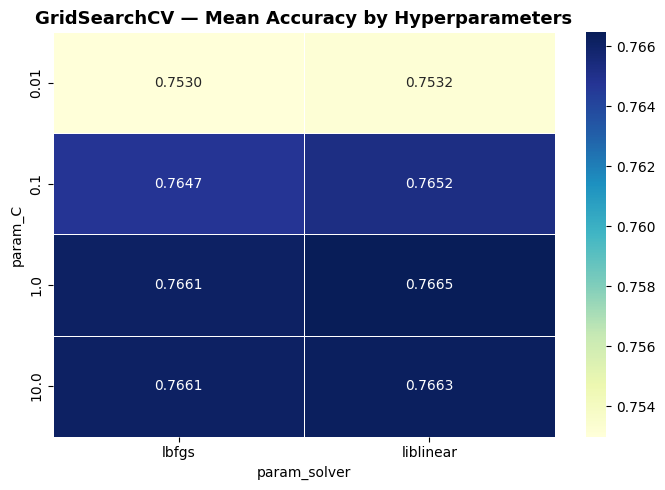

In [13]:
from sklearn.model_selection import GridSearchCV

print('Running GridSearchCV on Logistic Regression (may take a few minutes)...\n')

param_grid = {
    'C':      [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train_tfidf, y_train)

print(f'\nBest parameters : {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

# Evaluate tuned model on test set
best_logreg      = grid_search.best_estimator_
best_logreg_pred = best_logreg.predict(X_test_tfidf)
print(f'Tuned test accuracy: {accuracy_score(y_test, best_logreg_pred):.4f}')
print(f'Default accuracy   : {accuracy_score(y_test, logreg_pred):.4f}')

# Visualize grid search results
results_df = pd.DataFrame(grid_search.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_solver'
)
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5)
plt.title('GridSearchCV — Mean Accuracy by Hyperparameters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150)
plt.show()

## Step 14: Feature Importance — Top Predictive Words

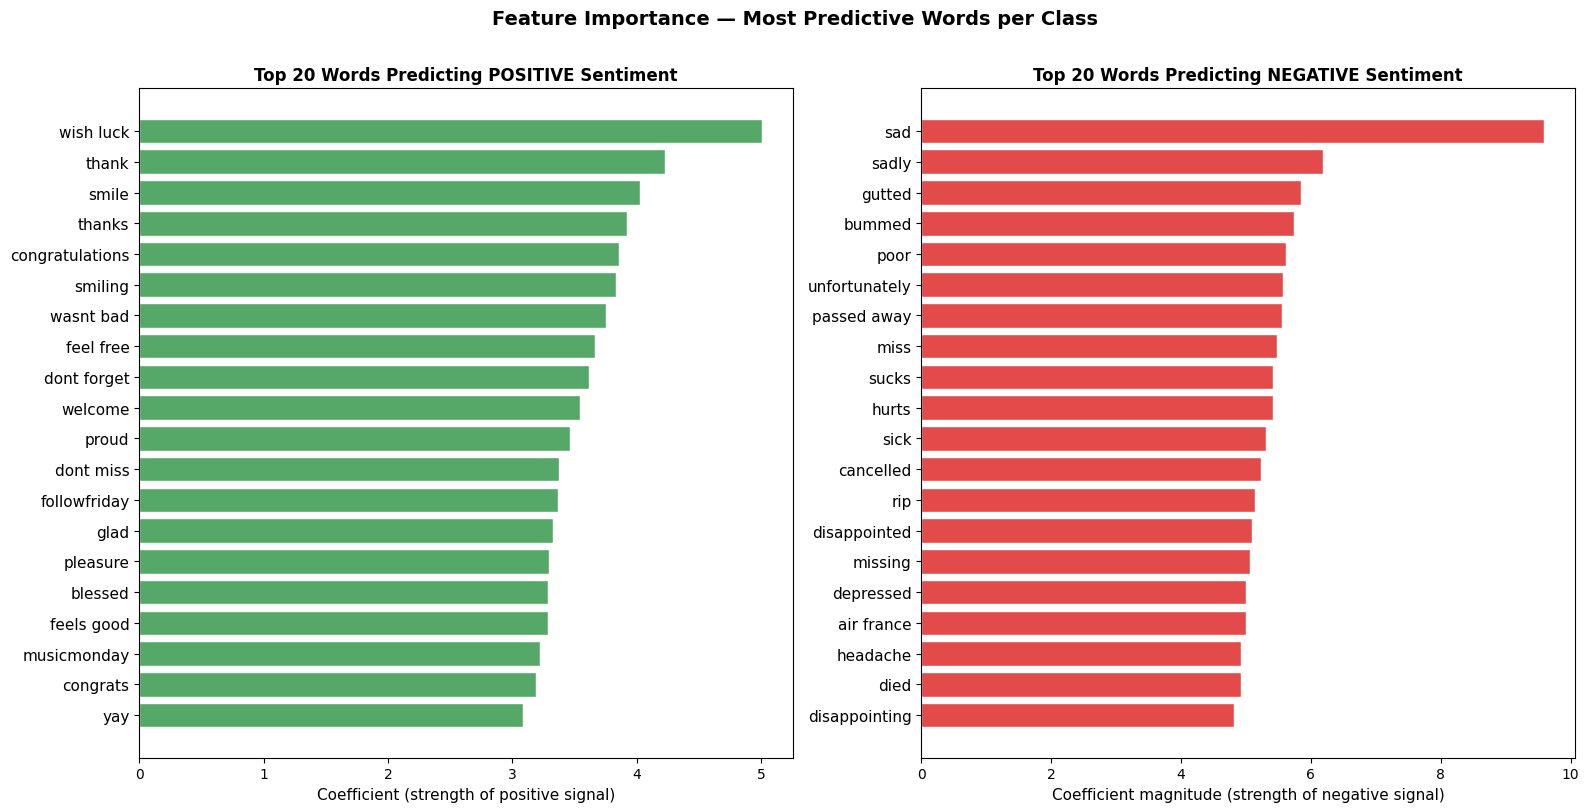

Feature importance chart saved.


In [14]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefs         = best_logreg.coef_[0]

top_n = 20
top_pos_idx  = np.argsort(coefs)[-top_n:][::-1]
top_neg_idx  = np.argsort(coefs)[:top_n]

top_pos_words  = feature_names[top_pos_idx]
top_pos_scores = coefs[top_pos_idx]
top_neg_words  = feature_names[top_neg_idx]
top_neg_scores = coefs[top_neg_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.barh(range(top_n), top_pos_scores, color='#55A868', edgecolor='white')
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(top_pos_words, fontsize=11)
ax1.set_xlabel('Coefficient (strength of positive signal)', fontsize=11)
ax1.set_title('Top 20 Words Predicting POSITIVE Sentiment', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

ax2.barh(range(top_n), np.abs(top_neg_scores), color='#E24B4A', edgecolor='white')
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(top_neg_words, fontsize=11)
ax2.set_xlabel('Coefficient magnitude (strength of negative signal)', fontsize=11)
ax2.set_title('Top 20 Words Predicting NEGATIVE Sentiment', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

plt.suptitle('Feature Importance — Most Predictive Words per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Feature importance chart saved.')

## Step 15: Error Analysis — What Does the Model Get Wrong?

In [15]:
# Find misclassified samples
X_test_arr = X_test.values
y_test_arr = y_test.values

mask_wrong       = y_test_arr != best_logreg_pred
false_positives  = [(X_test_arr[i], y_test_arr[i], best_logreg_pred[i])
                    for i in range(len(y_test_arr)) if y_test_arr[i]==0 and best_logreg_pred[i]==1]
false_negatives  = [(X_test_arr[i], y_test_arr[i], best_logreg_pred[i])
                    for i in range(len(y_test_arr)) if y_test_arr[i]==1 and best_logreg_pred[i]==0]

print(f'Total misclassified  : {mask_wrong.sum():,} out of {len(y_test_arr):,}')
print(f'Error rate           : {mask_wrong.mean()*100:.2f}%\n')

print('=== FALSE POSITIVES (predicted Positive, actually Negative) ===')
for tweet, true, pred in false_positives[:8]:
    print(f'  Tweet: {tweet[:100]}')
    print(f'  True: Negative | Predicted: Positive')
    print()

print('=== FALSE NEGATIVES (predicted Negative, actually Positive) ===')
for tweet, true, pred in false_negatives[:8]:
    print(f'  Tweet: {tweet[:100]}')
    print(f'  True: Positive | Predicted: Negative')
    print()

Total misclassified  : 74,543 out of 320,000
Error rate           : 23.29%

=== FALSE POSITIVES (predicted Positive, actually Negative) ===
  Tweet: cool i have no tweet apps for my razr
  True: Negative | Predicted: Positive

  Tweet: i know just family drama its lamehey next time u hang out with kim n u guys like have a sleepover or
  True: Negative | Predicted: Positive

  Tweet: upper airways problem
  True: Negative | Predicted: Positive

  Tweet: yeah mathieu totally choked in the rd set to let rog win as well djokovic played terribly
  True: Negative | Predicted: Positive

  Tweet: this day will pass slowly all of these days will rawr
  True: Negative | Predicted: Positive

  Tweet: i am ill admit maybe ill feel better tomorrow yo down studio time
  True: Negative | Predicted: Positive

  Tweet: too full of fizz but not enough cider
  True: Negative | Predicted: Positive

  Tweet: time to sleep long day again tomorrow
  True: Negative | Predicted: Positive

=== FALSE NEGATIVES (

## Step 16: 3-Class Sentiment — Neutral Class Extension

Generating 3-class labels using VADER compound scores...
(This may take a few minutes on the full dataset)

3-class label distribution:
label_3class
Positive    140142
Neutral      81137
Negative     78721
Name: count, dtype: int64


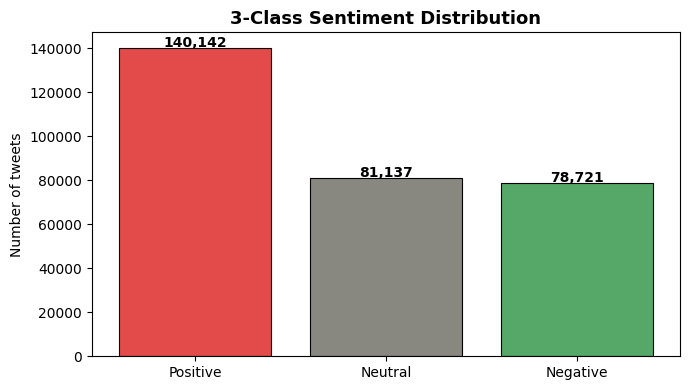

In [16]:
print('Generating 3-class labels using VADER compound scores...')
print('(This may take a few minutes on the full dataset)\n')

# Sample 300k tweets for the 3-class task (manageable size)
df_sample = df.sample(300000, random_state=42).copy()

def vader_3class(text):
    score = vader.polarity_scores(text)['compound']
    if score > 0.05:
        return 2   # Positive
    elif score < -0.05:
        return 0   # Negative
    else:
        return 1   # Neutral

df_sample['label_3class'] = df_sample['clean_text'].apply(vader_3class)

print('3-class label distribution:')
counts = df_sample['label_3class'].value_counts().rename({0:'Negative', 1:'Neutral', 2:'Positive'})
print(counts)

# Visualize
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color=['#E24B4A', '#888780', '#55A868'], edgecolor='black', linewidth=0.8)
plt.title('3-Class Sentiment Distribution', fontsize=13, fontweight='bold')
plt.ylabel('Number of tweets')
for i, v in enumerate(counts.values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('3class_distribution.png', dpi=150)
plt.show()

## Step 17: Train and Evaluate 3-Class Models


3-class training samples: 240,000
3-class testing samples : 60,000

Training Logistic Regression (3-class)...
  Accuracy: 0.8789
Training SVM (3-class)...
  Accuracy: 0.8813

Logistic Regression 3-Class Report:
              precision    recall  f1-score   support

    Negative       0.87      0.76      0.81     15744
     Neutral       0.84      0.94      0.89     16228
    Positive       0.91      0.91      0.91     28028

    accuracy                           0.88     60000
   macro avg       0.87      0.87      0.87     60000
weighted avg       0.88      0.88      0.88     60000

SVM 3-Class Report:
              precision    recall  f1-score   support

    Negative       0.87      0.77      0.82     15744
     Neutral       0.84      0.94      0.89     16228
    Positive       0.91      0.91      0.91     28028

    accuracy                           0.88     60000
   macro avg       0.87      0.87      0.87     60000
weighted avg       0.88      0.88      0.88     60000



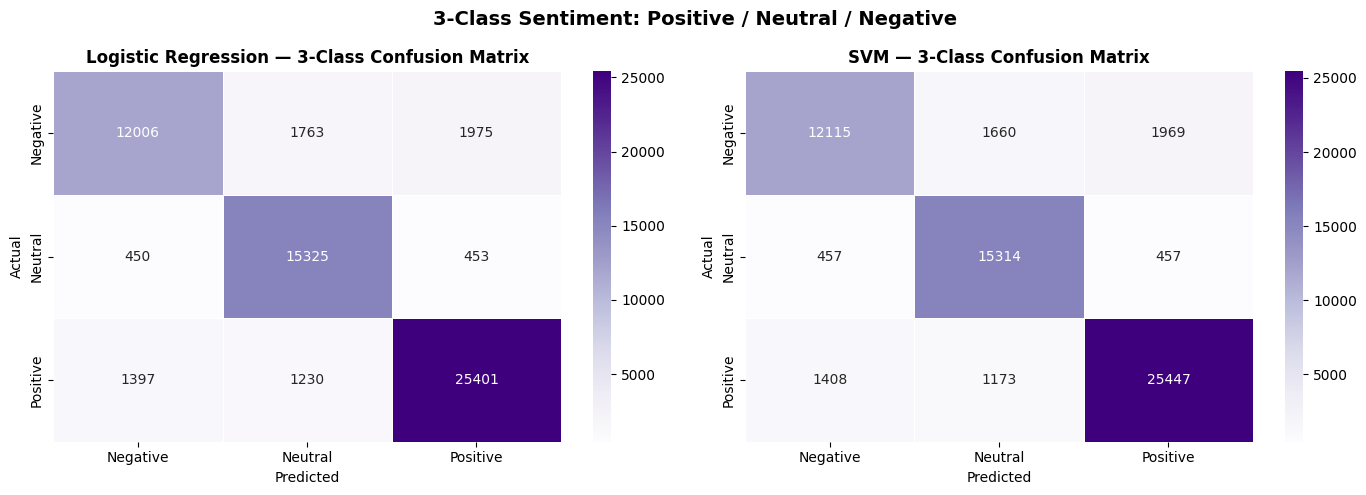

3-class confusion matrices saved.


In [17]:
from sklearn.model_selection import train_test_split

X3 = df_sample['clean_text']
y3 = df_sample['label_3class']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

# Vectorize
vec3 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X3_train_tfidf = vec3.fit_transform(X3_train)
X3_test_tfidf  = vec3.transform(X3_test)

print(f'3-class training samples: {len(X3_train):,}')
print(f'3-class testing samples : {len(X3_test):,}\n')

# Train models
print('Training Logistic Regression (3-class)...')
lr3 = LogisticRegression(max_iter=1000, C=1)
lr3.fit(X3_train_tfidf, y3_train)
lr3_pred = lr3.predict(X3_test_tfidf)
print(f'  Accuracy: {accuracy_score(y3_test, lr3_pred):.4f}')

print('Training SVM (3-class)...')
svm3 = LinearSVC(max_iter=2000)
svm3.fit(X3_train_tfidf, y3_train)
svm3_pred = svm3.predict(X3_test_tfidf)
print(f'  Accuracy: {accuracy_score(y3_test, svm3_pred):.4f}\n')

# Classification reports
class_names = ['Negative', 'Neutral', 'Positive']
print('Logistic Regression 3-Class Report:')
print(classification_report(y3_test, lr3_pred, target_names=class_names))

print('SVM 3-Class Report:')
print(classification_report(y3_test, svm3_pred, target_names=class_names))

# 3-class confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in [(ax1, lr3_pred, 'Logistic Regression'), (ax2, svm3_pred, 'SVM')]:
    cm = confusion_matrix(y3_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
    ax.set_title(f'{title} — 3-Class Confusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('3-Class Sentiment: Positive / Neutral / Negative', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('3class_confusion.png', bbox_inches='tight', dpi=150)
plt.show()
print('3-class confusion matrices saved.')

## Step 18: Save the Best Model


In [18]:
import joblib

# Save binary model
joblib.dump(best_logreg, 'sentiment_model_binary.pkl')
joblib.dump(vectorizer,  'tfidf_vectorizer_binary.pkl')

# Save 3-class model
joblib.dump(lr3,  'sentiment_model_3class.pkl')
joblib.dump(vec3, 'tfidf_vectorizer_3class.pkl')

print('Binary model saved  : sentiment_model_binary.pkl + tfidf_vectorizer_binary.pkl')
print('3-class model saved : sentiment_model_3class.pkl + tfidf_vectorizer_3class.pkl')

Binary model saved  : sentiment_model_binary.pkl + tfidf_vectorizer_binary.pkl
3-class model saved : sentiment_model_3class.pkl + tfidf_vectorizer_3class.pkl


## Step 19: Live Prediction Demo

In [19]:
# Load saved models
bin_model = joblib.load('sentiment_model_binary.pkl')
bin_vec   = joblib.load('tfidf_vectorizer_binary.pkl')
tri_model = joblib.load('sentiment_model_3class.pkl')
tri_vec   = joblib.load('tfidf_vectorizer_3class.pkl')

def predict_binary(tweet):
    cleaned = clean_text(tweet)
    vec     = bin_vec.transform([cleaned])
    pred    = bin_model.predict(vec)[0]
    return 'Positive' if pred == 1 else 'Negative'

def predict_3class(tweet):
    cleaned = clean_text(tweet)
    vec     = tri_vec.transform([cleaned])
    pred    = tri_model.predict(vec)[0]
    return {0: 'Negative', 1: 'Neutral', 2: 'Positive'}[pred]

test_tweets = [
    'I absolutely love this! Best day ever!',
    'This is terrible. Worst experience of my life.',
    'The meeting is scheduled for 3pm tomorrow.',
    'So excited for the weekend trip!',
    'Traffic is making me so frustrated today.',
    'Just had lunch at the cafeteria.',
    'Omg I just got promoted!! I am so happy!',
    'My flight got cancelled again. Unbelievable.',
    'The weather seems okay today.',
]

print(f'{"Tweet":<55} {"Binary":<12} {"3-Class"}')
print('-' * 85)
for tweet in test_tweets:
    b = predict_binary(tweet)
    t = predict_3class(tweet)
    print(f'{tweet[:54]:<55} {b:<12} {t}')

Tweet                                                   Binary       3-Class
-------------------------------------------------------------------------------------
I absolutely love this! Best day ever!                  Positive     Positive
This is terrible. Worst experience of my life.          Negative     Negative
The meeting is scheduled for 3pm tomorrow.              Negative     Neutral
So excited for the weekend trip!                        Positive     Positive
Traffic is making me so frustrated today.               Negative     Negative
Just had lunch at the cafeteria.                        Positive     Neutral
Omg I just got promoted!! I am so happy!                Positive     Positive
My flight got cancelled again. Unbelievable.            Negative     Negative
The weather seems okay today.                           Negative     Positive


## Step 20: Final Project Summary

In [20]:
names      = ['Naive Bayes', 'SVM', 'Logistic Regression (default)', 'Logistic Regression (tuned)', 'VADER']
preds_list = [bnb_pred, svm_pred, logreg_pred, best_logreg_pred, vader_pred]

print('=' * 60)
print('  PROJECT SUMMARY — TWITTER SENTIMENT ANALYSIS')
print('=' * 60)
print(f'  Dataset           : Sentiment140')
print(f'  Binary tweets     : {len(df):,}')
print(f'  3-class tweets    : {len(df_sample):,} (sampled)')
print(f'  TF-IDF features   : 5,000 unigrams + bigrams')
print(f'  Preprocessing     : emoji, slang, stopwords, cleaning')
print()
print('  Binary Classification Results:')
for name, pred in zip(names, preds_list):
    acc = accuracy_score(y_test, pred)
    print(f'    {name:<35}: {acc*100:.2f}%')
print()
print('  3-Class Results (Pos / Neu / Neg):')
print(f'    Logistic Regression : {accuracy_score(y3_test, lr3_pred)*100:.2f}%')
print(f'    SVM                 : {accuracy_score(y3_test, svm3_pred)*100:.2f}%')
print('=' * 60)

  PROJECT SUMMARY — TWITTER SENTIMENT ANALYSIS
  Dataset           : Sentiment140
  Binary tweets     : 1,600,000
  3-class tweets    : 300,000 (sampled)
  TF-IDF features   : 5,000 unigrams + bigrams
  Preprocessing     : emoji, slang, stopwords, cleaning

  Binary Classification Results:
    Naive Bayes                        : 75.65%
    SVM                                : 76.61%
    Logistic Regression (default)      : 76.68%
    Logistic Regression (tuned)        : 76.71%
    VADER                              : 66.40%

  3-Class Results (Pos / Neu / Neg):
    Logistic Regression : 87.89%
    SVM                 : 88.13%
